Found 7750 images belonging to 2 classes.
Found 744 images belonging to 2 classes.
Found 364 images belonging to 2 classes.


C:\Users\Bsi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 675s 3s/step - accuracy: 0.8139 - loss: 0.4387 - val_accuracy: 0.8239 - val_loss: 0.2728
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 548s 2s/step - accuracy: 0.9367 - loss: 0.1675 - val_accuracy: 0.9046 - val_loss: 0.1944
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 525s 2s/step - accuracy: 0.9514 - loss: 0.1295 - val_accuracy: 0.8602 - val_loss: 0.2400
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 525s 2s/step - accuracy: 0.9546 - loss: 0.1125 - val_accuracy: 0.9503 - val_loss: 0.1539
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 527s 2s/step - accuracy: 0.9622 - loss: 0.0969 - val_accuracy: 0.9086 - val_loss: 0.1565
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 525s 2s/step - accuracy: 0.9683 - loss: 0.0912 - val_accuracy: 0.9597 - val_loss: 0.1304
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 608s 3s/step - accuracy: 0.9675 - loss: 0.0834 - val_accuracy: 0.9704 - val_loss: 0.1276
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 643s 3s/step - accuracy: 0.9729 - loss: 0.0787 - val_accu

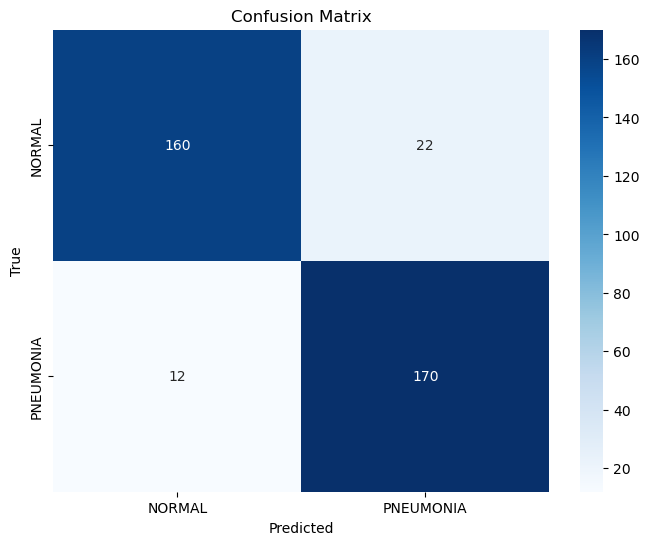

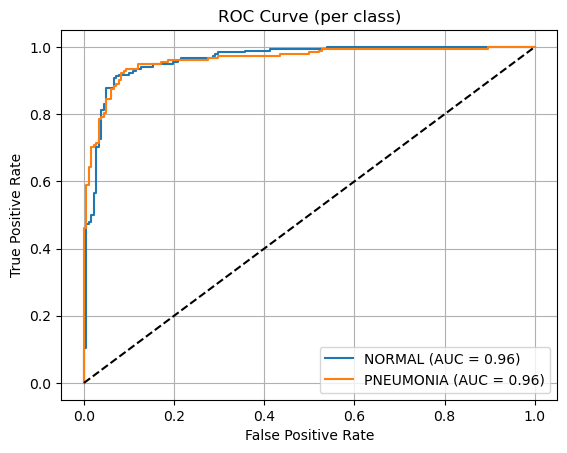

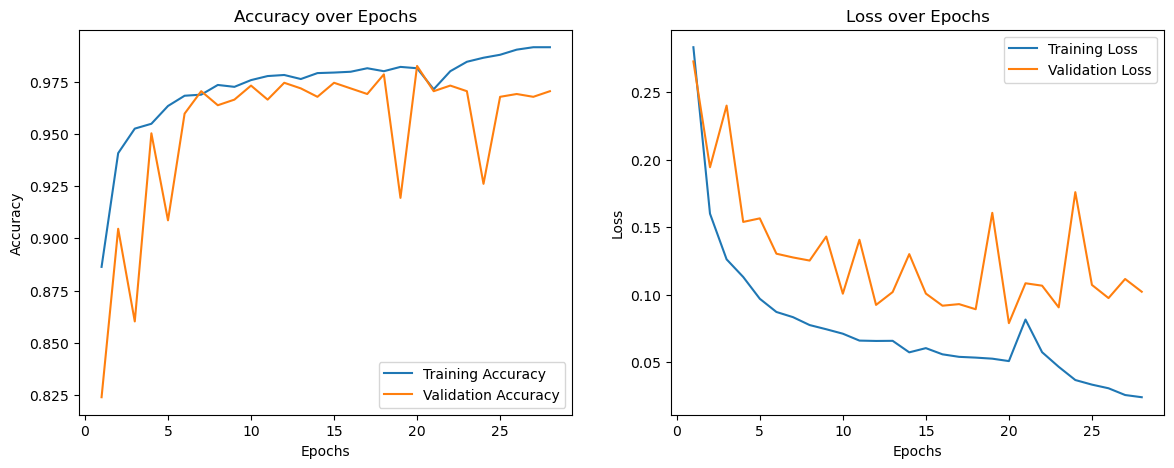

In [1]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.applications.resnet import preprocess_input
#preparation de donnees
train_dir = 'D:/Data-Chest-ray/train'
val_dir = 'D:/Data-Chest-ray/val'
test_dir = 'D:/Data-Chest-ray/test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   rotation_range=15,
                                   zoom_range=0.1,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE,
                                              batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE,
                                          batch_size=BATCH_SIZE, class_mode='categorical')
test_gen = val_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE,
                                           batch_size=1, class_mode='categorical', shuffle=False)
base_model = ResNet101(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_1 = model.fit(train_gen,
                      validation_data=val_gen,
                      epochs=20,
                      callbacks=[early_stop])
base_model.trainable = True

# Gèle les couches profondes sauf les dernières
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_2 = model.fit(train_gen,
                      validation_data=val_gen,
                      epochs=15,
                      callbacks=[early_stop])
# Prédictions
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
target_names = list(test_gen.class_indices.keys())

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=target_names))

# F1-score
f1 = f1_score(y_true, y_pred, average='macro')
print("F1-score (macro):", f1)

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Courbes ROC pour chaque classe
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(len(target_names)):
    fpr[i], tpr[i], _ = roc_curve(test_gen.labels == i, pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (per class)')
plt.legend()
plt.grid(True)
plt.show()
def plot_learning_curves(history_list, labels):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Appeler la fonction
plot_learning_curves([history_1, history_2], ['Phase 1', 'Phase 2'])

In [3]:
import matplotlib.pyplot as plt

fig_dir = 'D:/Data-Chest-ray'
os.makedirs(fig_dir, exist_ok=True)

# Courbe d'apprentissage
def save_learning_curves(history_list, save_path):
    acc, val_acc, loss, val_loss = [], [], [], []
    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    plt.savefig(os.path.join(save_path, 'learning_curves.png'))
    plt.close()

save_learning_curves([history_1, history_2], fig_dir)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'confusion_matrix.png'))
plt.close()
plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'roc_curve.png'))
plt.close()


In [7]:
# save
model_save_path = 'D:/Data-Chest-ray'
os.makedirs(model_save_path, exist_ok=True)

# Sauvegarder le modèle final
model.save(os.path.join(model_save_path, 'ResNet101perfect_finetuned_model.keras'))
print("✅ Modèle enregistré avec succès dans pc.")

✅ Modèle enregistré avec succès dans pc.


In [9]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.applications.resnet import preprocess_input
#preparation de donnees
train_dir = 'D:/Data-Chest-ray/train'
val_dir = 'D:/Data-Chest-ray/val'
test_dir = 'D:/Data-Chest-ray/test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   rotation_range=15,
                                   zoom_range=0.1,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE,
                                              batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE,
                                          batch_size=BATCH_SIZE, class_mode='categorical')
test_gen = val_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE,
                                           batch_size=1, class_mode='categorical', shuffle=False)
base_model = ResNet101(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_1 = model.fit(train_gen,
                      validation_data=val_gen,
                      epochs=20,
                      callbacks=[early_stop])
base_model.trainable = True

# Gèle les couches profondes sauf les dernières
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_2 = model.fit(train_gen,
                      validation_data=val_gen,
                      epochs=15,
                      callbacks=[early_stop])
# Prédictions
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
target_names = list(test_gen.class_indices.keys())

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=target_names))

# F1-score
f1 = f1_score(y_true, y_pred, average='macro')
print("F1-score (macro):", f1)

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Courbes ROC pour chaque classe
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(len(target_names)):
    fpr[i], tpr[i], _ = roc_curve(test_gen.labels == i, pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (per class)')
plt.legend()
plt.grid(True)
plt.show()
def plot_learning_curves(history_list, labels):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Appeler la fonction
plot_learning_curves([history_1, history_2], ['Phase 1', 'Phase 2'])

Found 7750 images belonging to 2 classes.
Found 744 images belonging to 2 classes.
Found 364 images belonging to 2 classes.


C:\Users\Bsi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 584s 2s/step - accuracy: 0.8212 - loss: 0.4242 - val_accuracy: 0.9153 - val_loss: 0.2034
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 544s 2s/step - accuracy: 0.9324 - loss: 0.1788 - val_accuracy: 0.9530 - val_loss: 0.1724
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 543s 2s/step - accuracy: 0.9513 - loss: 0.1345 - val_accuracy: 0.9207 - val_loss: 0.1739
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 550s 2s/step - accuracy: 0.9595 - loss: 0.1197 - val_accuracy: 0.9247 - val_loss: 0.1525
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 545s 2s/step - accuracy: 0.9617 - loss: 0.1081 - val_accuracy: 0.9691 - val_loss: 0.1497
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 547s 2s/step - accuracy: 0.9678 - loss: 0.0960 - val_accuracy: 0.9530 - val_loss: 0.1488
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 547s 2s/step - accuracy: 0.9656 - loss: 0.0974 - val_accuracy: 0.9570 - val_loss: 0.1454
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 540s 2s/step - accuracy: 0.9708 - loss: 0.0815 - val_accu

UnknownError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
OSError: broken data stream when reading image file
Traceback (most recent call last):

  File "C:\Users\Bsi\anaconda3\Lib\site-packages\tensorflow\python\ops\script_ops.py", line 269, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "C:\Users\Bsi\anaconda3\Lib\site-packages\tensorflow\python\autograph\impl\api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "C:\Users\Bsi\anaconda3\Lib\site-packages\tensorflow\python\data\ops\from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "C:\Users\Bsi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py", line 248, in _finite_generator
    yield self._standardize_batch(self.py_dataset[i])
          

In [15]:
# Gèle les couches profondes sauf les dernières
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_2 = model.fit(train_gen,
                      validation_data=val_gen,
                      epochs=15,
                      callbacks=[early_stop])

Epoch 1/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 689s 3s/step - accuracy: 0.9925 - loss: 0.0250 - val_accuracy: 0.9704 - val_loss: 0.1037
Epoch 2/15
183/243 ━━━━━━━━━━━━━━━━━━━━ 2:31 3s/step - accuracy: 0.9910 - loss: 0.0242

UnknownError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
OSError: broken data stream when reading image file
Traceback (most recent call last):

  File "C:\Users\Bsi\anaconda3\Lib\site-packages\tensorflow\python\ops\script_ops.py", line 269, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "C:\Users\Bsi\anaconda3\Lib\site-packages\tensorflow\python\autograph\impl\api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "C:\Users\Bsi\anaconda3\Lib\site-packages\tensorflow\python\data\ops\from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "C:\Users\Bsi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py", line 248, in _finite_generator
    yield self._standardize_batch(self.py_dataset[i])
          

In [11]:
# Prédictions
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
target_names = list(test_gen.class_indices.keys())

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=target_names))

# F1-score
f1 = f1_score(y_true, y_pred, average='macro')
print("F1-score (macro):", f1)

364/364 ━━━━━━━━━━━━━━━━━━━━ 45s 118ms/step
              precision    recall  f1-score   support

      NORMAL       0.96      0.80      0.87       182
   PNEUMONIA       0.83      0.97      0.89       182

    accuracy                           0.88       364
   macro avg       0.89      0.88      0.88       364
weighted avg       0.89      0.88      0.88       364

F1-score (macro): 0.8810050556886


In [13]:
# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Courbes ROC pour chaque classe
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(len(target_names)):
    fpr[i], tpr[i], _ = roc_curve(test_gen.labels == i, pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (per class)')
plt.legend()
plt.grid(True)
plt.show()
def plot_learning_curves(history_list, labels):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
       plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Appeler la fonction
plot_learning_curves([history_1, history_2], ['Phase 1', 'Phase 2'])

IndentationError: unexpected indent (3096224607.py, line 43)